In [1]:
import polars as pl
import plotly.express as px

DATA_PATH = "../data/processed/claims_sample.parquet"

df = pl.read_parquet(DATA_PATH)
print(df.shape)
df.select(["state", "amountPaidOnBuildingClaim", "amountPaidOnBuildingClaim_nominal", "yearOfLoss"]).head()

(22533, 46)


state,amountPaidOnBuildingClaim,amountPaidOnBuildingClaim_nominal,yearOfLoss
str,f64,f64,i16
"""MS""",706865.107545,440000.0,2005
"""TX""",10013.560344,3434.7,1985
"""FL""",38373.696039,29984.87,2017
"""AZ""",35377.849183,8185.71,1979
"""NJ""",34587.42791,15469.98,1992


In [2]:
print("nulls:", df["state"].null_count())
print("n unique:", df["state"].n_unique())
print(sorted(df["state"].unique().to_list()))

nulls: 0
n unique: 57
['AK', 'AL', 'AR', 'AS', 'AZ', 'CA', 'CO', 'CT', 'DC', 'DE', 'FL', 'GA', 'GU', 'HI', 'IA', 'ID', 'IL', 'IN', 'KS', 'KY', 'LA', 'MA', 'MD', 'ME', 'MI', 'MN', 'MO', 'MP', 'MS', 'MT', 'NC', 'ND', 'NE', 'NH', 'NJ', 'NM', 'NV', 'NY', 'OH', 'OK', 'OR', 'PA', 'PR', 'RI', 'SC', 'SD', 'TN', 'TX', 'UN', 'UT', 'VA', 'VI', 'VT', 'WA', 'WI', 'WV', 'WY']


In [3]:
US_STATES = {
    "AL","AK","AZ","AR","CA","CO","CT","DE","FL","GA","HI","ID","IL","IN","IA",
    "KS","KY","LA","ME","MD","MA","MI","MN","MS","MO","MT","NE","NV","NH","NJ",
    "NM","NY","NC","ND","OH","OK","OR","PA","RI","SC","SD","TN","TX","UT","VT",
    "VA","WA","WV","WI","WY","DC",
}
non_state = df.filter(~pl.col("state").is_in(US_STATES))
print(non_state.height, "rows outside the 50 states + DC")
print(non_state["state"].value_counts().sort("count", descending=True))

301 rows outside the 50 states + DC
shape: (6, 2)
┌───────┬───────┐
│ state ┆ count │
│ ---   ┆ ---   │
│ str   ┆ u32   │
╞═══════╪═══════╡
│ PR    ┆ 144   │
│ UN    ┆ 133   │
│ VI    ┆ 18    │
│ GU    ┆ 4     │
│ AS    ┆ 1     │
│ MP    ┆ 1     │
└───────┴───────┘


In [4]:
state_medians = (
    df.filter(pl.col("state").is_in(US_STATES))
    .group_by("state")
    .agg(
        median_severity=pl.col("amountPaidOnBuildingClaim").median(),
        n_claims=pl.len(),
    )
    .sort("median_severity", descending=True)
)
print(state_medians.height, "states")
state_medians.head(10)

51 states


state,median_severity,n_claims
str,f64,u32
"""LA""",39972.445986,4092
"""TX""",35185.363656,3424
"""NV""",31658.061361,13
"""MS""",30093.580283,555
"""HI""",27937.26526,41
"""FL""",25950.052024,3382
"""NY""",23611.533349,1524
"""AK""",21708.046971,10
"""NJ""",20972.211205,1833


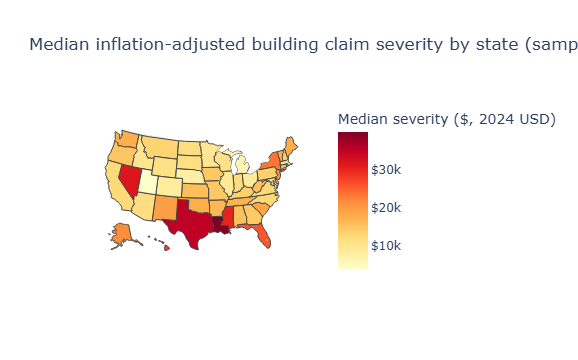

In [5]:
fig = px.choropleth(
    state_medians,
    locations="state",
    locationmode="USA-states",
    color="median_severity",
    scope="usa",
    color_continuous_scale="YlOrRd",
    hover_data={"n_claims": True},
    labels={"median_severity": "Median severity ($, 2024 USD)", "state": "State"},
    title="Median inflation-adjusted building claim severity by state (sample data)",
)
fig.update_layout(coloraxis_colorbar=dict(tickprefix="$"))
fig.show()